## Preliminaries 

For this notebook,  we use the same github repo as in exercise 6, the implementation of the EM algorithm to fit the poisson-gpfa: 

Thus, to run this, you can clone `git clone https://github.com/berenslab/poisson-gpfa`. 

Our directory structure looks like this: 


```
├── data/
│   └── data_with_spikes_and_speed.txt
├── utils/
│   └── utils.py
|   └── poisson-gpfa/
├── notebooks
│   └── gpfa_analysis.ipynb
```
then you can import the related functions via:

```
import sys
sys.path.append('../poisson-gpfa/')
sys.path.append('../poisson-gpfa/funs')

import funs.util as util
import funs.engine as engine
```

Change the paths if you have a different directory structure. 


In [19]:
from pathlib import Path
import sys, os

notebook_dir = Path.cwd()
project_root = notebook_dir.parent
sys.path.append(str(project_root))

# Add poisson-gpfa package
poisson_gpfa_path = project_root / "utils" / "poisson-gpfa"
sys.path.append(str(poisson_gpfa_path))
sys.path.append(str(poisson_gpfa_path / "funs"))

from utils.utils import *

import funs.util as util
import funs.engine as engine

## Motivation: Ecker et al. (2014)

### Intro
- **Noise correlations** quantify the trial-to-trial covariability of responses between pairs of neurons when the same stimulus is presented repeatedly.
- They are important because they can influence the accuracy of neural population codes.
- Correlations can reflect meaningful **internal/top-down signals** that simultaneously modulate the activity of many neurons.
- Firing rate alone cannot explain differences in noise correlations across brain states.

### Experimental manipulation
- Ecker et al. measured V1 neurons in **awake and anesthetized monkeys**.
- Most neurons were tuned to orientation, with qualitatively similar tuning between awake and anesthetized states.
- Under anesthesia:
  - responses were more variable (higher Fano factor),
  - average noise correlations increased compared to wakefulness.

### GPFA model
To identify shared population dynamics, they used **Gaussian Process Factor Analysis (GPFA)**, a latent variable model that describes neural activity as driven by a low-dimensional latent state:

$$
y_k(t)=f_k(s(t))+c_kx(t)+d_k+\nu_k(t)
$$

where:
- $y_k(t)$: firing rate of neuron $k$,
- $f_k(s(t))$: stimulus-dependent tuning component,
- $x(t)$: shared latent network state,
- $c_k$: loading describing how strongly neuron $k$ is influenced by the latent state,
- $d_k$: baseline firing rate,
- $\nu_k(t)$: independent observation noise.

The latent state $x(t)$ evolves smoothly according to a Gaussian process with covariance:

$$
K_{ij}=\mathrm{Cov}[x(t_i),x(t_j)]
=
\exp\left(-\frac{(t_i-t_j)^2}{2\tau^2}\right)
$$

where $\tau$ determines the temporal smoothness of the latent dynamics.

## Our main idea

GPFA tests whether shared low-dimensional latent trajectories can explain trial-to-trial fluctuations underlying noise correlations between neurons. It further examines whether locomotion-related dynamics are reflected in the learned latent trajectories by comparing them with the smoothed running speed trace.

We used the session 1 drifting grating dataset due to its large sample size per trial. Independent GPFA models were fitted for each stimulus condition (orientation, temporal frequency and blank sweep) and the locomotion state to reduce the bias of the stimulus type. 

### Model fitting

- Extracted spike counts for each trial during a fixed stimulus period of $T=30$ non-overlapping bins (bin size: $33$ ms).
- Recorded running speed and running phase (still/running) for each trial.
- Fitted separate GPFA models for each stimulus condition and phases of black stimulus (blank sweeps)
- For each model:
  - Performed 10 EM iterations:
    - **E-step:** inferred the latent state trajectory $x(t)$ given the current parameters.
    - **M-step:** optimized the model parameters ($\tau$, $c_k$, and $d_k$) given the inferred latent state.
  - Used a single latent dimension ($x(t) \in \mathbb{R}^1$).
  - Initialized parameters using Poisson-PCA.
- We evaluated models on training sets only due to the limited amount of data available (after applying all our constraints, each model had only around $10$ trials; except for the blank sweep condition)

## Notebook structure
This notebook trains all GPFA models in a single loop and stores them in a dictionary indexed by stimulus and locomotion conditions (orientation, temporal frequency, and running phase). 

Using the fitted parameters, we estimate the covariance structure for each model and identify conditions with the highest explained variance. 

We then analyze the distribution of fitted parameters and finally compare the learned latent trajectories with the running speed trace.

Throughout this notebook, color blue denotes still phases (e.g phases where the mouse was not moving), and red denotes running phases (e.g phases where mouse was running with speed $\ge 2 cm/s$)

In [20]:
data = load_saved_data("data_with_spikes_and_speed")

In [21]:
stim_table = data["sessions"]["A"]["stim_tables"]["drifting_gratings"]
print(f" Unique orientation: {stim_table['orientation'].unique()}")
print(f" Unique temporal frequencies: {stim_table['temporal_frequency'].unique()}")
print(f" Unique blank sweeps: {stim_table['blank_sweep'].unique()}")

# 1. Train GPFA on each stimulus condition of drifting gratings

In [22]:
# Some Hyperparameters
NR_TEST_TRIALS = 0
NR_EM_ITER = 10
BATCH_SIZE = 2
TEMPORAL_FREQUENCIES = [1, 2, 4, 8, 15]  # Hz
ORIENTATIONS = [0, 45, 90, 135, 180, 225, 270, 315]  # degrees
RUNNING_PHASES = [0, 1] # 0: still, 1: running 
BLANK_SWEEPS = [0, 1] 
NR_BINS = 30

In [ ]:
def fit_gpfa_condition(data, parameters, parameter_values, running_phase, key, fits):
    """Build a GPFADataset for one condition, fit GPFA if enough trials, and store it in fits."""
    dataset = GPFADataset(
        data=data,
        session_id="A",
        stimulus="drifting_gratings",
        parameters=parameters,
        parameter_values=parameter_values,
        minimum_nr_of_bins=NR_BINS,
        running_phase_value=running_phase,
    )

    if dataset.numTrials <= NR_TEST_TRIALS:
        return

    print(f"Fitting GPFA model for {key}...")
    xval = util.crossValidation(
        experiment=dataset,
        numTrainingTrials=dataset.numTrials - NR_TEST_TRIALS,
        numTestTrials=NR_TEST_TRIALS,
        maxXdim=1,  # for simplicity, we set latent dim to 1
        maxEMiter=NR_EM_ITER,
        batchSize=BATCH_SIZE,
        inferenceMethod="laplace",
        learningMethod="batch",
    )
    sys.stdout = open(os.devnull, "w")
    sys.stdout = sys.__stdout__

    train_set, test_set = util.splitTrainingTestDataset(
        dataset,
        numTrainingTrials=dataset.numTrials - NR_TEST_TRIALS,
        numTestTrials=NR_TEST_TRIALS,
    )

    fits[key] = (train_set, test_set, xval)


# First loop over all possible temporal frequencies and orientations,
fits = {}
for running_phase in RUNNING_PHASES:
    for orientation in ORIENTATIONS:
        for temporal_frequency in TEMPORAL_FREQUENCIES:
            key = (orientation, temporal_frequency, running_phase, False)
            fit_gpfa_condition(
                data, ["orientation", "temporal_frequency"], [orientation, temporal_frequency],
                running_phase, key, fits,
            )
    # Second loop over blank sweeps, if any
    print(f"Processing blank sweeps for running_phase={running_phase}")
    key = (None, None, running_phase, True)
    fit_gpfa_condition(data, ["blank_sweep"], [1], running_phase, key, fits)
    

In [24]:
rows = []
for (orientation, temporal_frequency, running_phase, blank_sweep), (train_set, test_set, xval) in fits.items():
    rows.append({
        "Orientation": orientation,
        "Temporal Frequency": temporal_frequency,
        "Running Phase": "Running" if running_phase == 1 else "Still",
        "Blank Sweep": blank_sweep,
        "Train Trials": train_set.numTrials,
        "Test Trials": test_set.numTrials,
        "Trial Duration (ms)": round(train_set.trialDur, 1),
        "Bin Size (ms)": round(train_set.binSize, 1),
    })

fit_params = pd.DataFrame(rows)
fit_params

,Orientation,Temporal Frequency,Running Phase,Blank Sweep,Train Trials,Test Trials,Trial Duration (ms),Bin Size (ms)
0,0.0,1.0,Still,False,9,0,996.1,33.2
1,0.0,2.0,Still,False,7,0,996.1,33.2
2,0.0,4.0,Still,False,12,0,996.1,33.2
3,0.0,8.0,Still,False,8,0,996.1,33.2
4,0.0,15.0,Still,False,11,0,996.1,33.2
...,...,...,...,...,...,...,...,...
77,315.0,2.0,Running,False,3,0,996.1,33.2
78,315.0,4.0,Running,False,8,0,996.1,33.2
79,315.0,8.0,Running,False,11,0,996.1,33.2
80,315.0,15.0,Running,False,4,0,996.1,33.2


# 2. Noise correlations and their GPFA approximations

In [25]:
NR_MODELS_TO_PLOT = 2

The approximate covariance for a given stimulus condition is computed using the analytical solution of the log-normal Cox process approximation:

$$
\mu = \exp\left(\frac{1}{2}\operatorname{diag}(CC^T)+d\right),
$$

$$
\mathrm{Cov} = \mu\otimes\mu^T \odot \left(\exp(CC^T)-\mathbb{I}\right)+ \mu\cdot\mathbb{I}.
$$

The fraction of explained variance (FVE) is then a fraction between the variance approximation and the data variance controlled for the independent poisson noise.

In [26]:
def compute_cov_approx(fits):
    """Compute raw covariance, approximate covariance, and explained variance 
    for each condition of the fit
    """
    
    raw_covs = {}
    approx_covs, approx_mus = {}, {}
    explained_vars = {}
    for key, (train_set, _, xval_drifting_gratings) in fits.items():
        
        # raw covariance from the training set
        all_Y = np.concatenate([trial["Y"] for trial in train_set.data], axis=1)  # shape (ydim, total_bins)
        raw_covs[key] = np.cov(all_Y)  # shape (ydim, ydim)
        
        # approximate covariance from the fitted GPFA model
        fit = xval_drifting_gratings.fits[0]
        approx_cov, approx_mu = cov_anal(fit)  # shape (ydim, ydim)
        approx_covs[key] = approx_cov
        approx_mus[key] = approx_mu
        
        # explained variance
        explained_vars[key] = var_explained(raw_covs[key], approx_covs[key], approx_mus[key])
    
    return raw_covs, approx_covs, approx_mus, explained_vars

In [27]:
raw_covs, approx_covs, approx_mus, explained_variances = compute_cov_approx(fits)

We can compare the fraction of explained variances over all stimulus conditions between running and still phases.

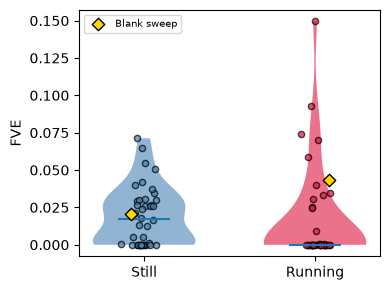

In [28]:
fig, ax = plot_explained_variance(
    explained_variances, 
    figure_size=(4, 3)
)
plt.show()

We observe that the fraction of explained variance (FVE) is low for most conditions. This may be due to the sparse nature of the deconvolved calcium imaging output (here, from OASIS). Since the inferred spike trains contain relatively few non-zero bins, the GPFA model has limited shared structure available to capture, which caps how much variance it can explain.

Notably, blank-sweep trials tend to show higher explained variance, with a further, small increase during the running phases.

In [29]:
# get the trial keys of the two conditions with the most explained variance for each running phase
top_trial_keys_per_phase = []
for running_phase in RUNNING_PHASES:
    # filter the explained_variances dictionary for the current running phase
    filtered_explained_variance = {k: v for k, v in explained_variances.items() if k[2] == running_phase}
    
    # sort the filtered dictionary by explained variance and get the top two keys
    top_trial_keys = [key for key, _ in sorted(filtered_explained_variance.items(), key=lambda item: item[1], reverse=True)]
    
    top_trial_keys_per_phase.append(top_trial_keys)

We can also plot the raw and approximated covariance matrices for some stimulus conditions (here for the ones with the most explained variances)

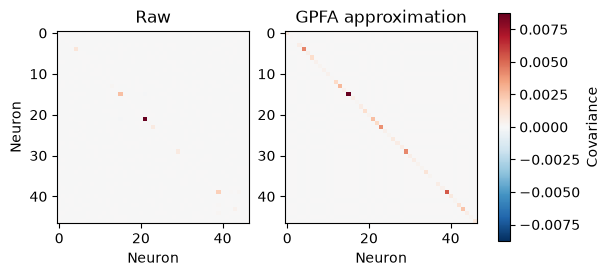

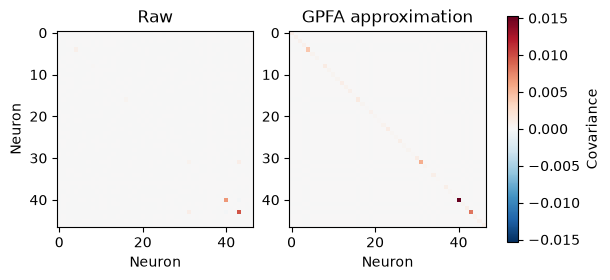

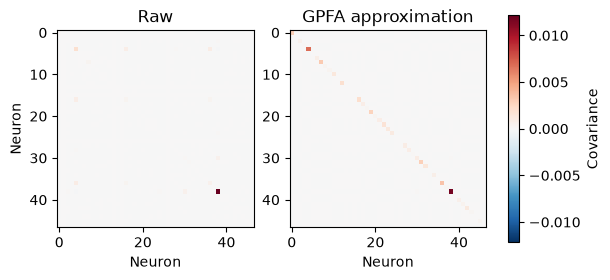

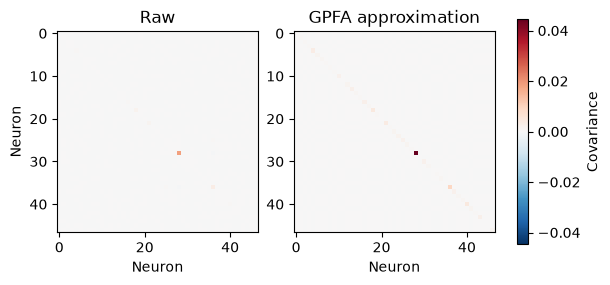

In [30]:
# only plot covariances for the conditions with the most explained variance 
# for each running phase
for running_phase in RUNNING_PHASES:
    trial_keys = top_trial_keys_per_phase[running_phase][:NR_MODELS_TO_PLOT]
    for trial_key in trial_keys:
        raw_cov = raw_covs[trial_key]
        approx_cov = approx_covs[trial_key]
        fig, axes = plot_covariances(raw_cov, approx_cov)
        plt.show()

This shows the pairwise covariance structure across all $47$ neurons for the best models in both locomotion states.

- The raw data show little shared covariance structure between neurons, leaving limited covariance patterns for the GPFA model to capture.
- The best-fitting models primarily reproduce the diagonal of the covariance matrix, corresponding to neuron-specific variance (baseline firing variability)

#  3. Parameter distributions

In [31]:
NR_MODELS_TO_PLOT = 2

Useful to gain insights into the structure of variability induced by the network state variable. 

Again plot this for the conditions that resulted in models with largest explained variance.

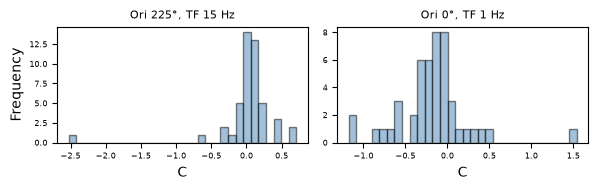

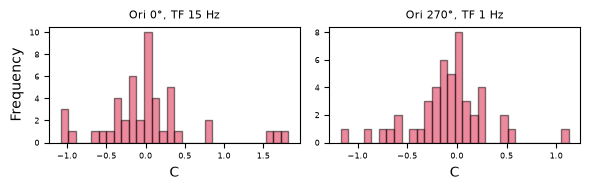

In [32]:
fig, axes = plot_param_histograms(
    fits, param_name="C", 
    bins=30, 
    running_phase=0, 
    trial_keys=top_trial_keys_per_phase[0][:NR_MODELS_TO_PLOT],
    figsize_per_cell=(3, 2))

plt.show()

fig, axes = plot_param_histograms(
    fits, param_name="C", 
    bins=30, 
    running_phase=1, 
    trial_keys=top_trial_keys_per_phase[1][:NR_MODELS_TO_PLOT],
    figsize_per_cell=(3, 2))

plt.show()

- The weight distribution $c_k$ describes how strongly the latent state influences the firing rate of each neuron.
- If locomotion induces a shared latent modulation, neurons should show a consistent shift in their weights during the active phase of the latent state (e.g., running).
- However, across all stimulus conditions, the weights remained centered around zero with no clear difference between locomotion phases, suggesting limited  modulation by the learned latent state.

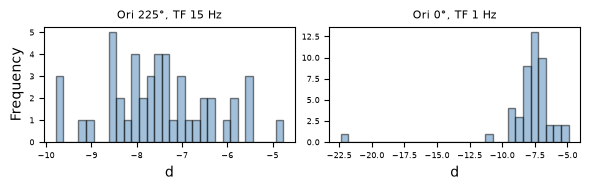

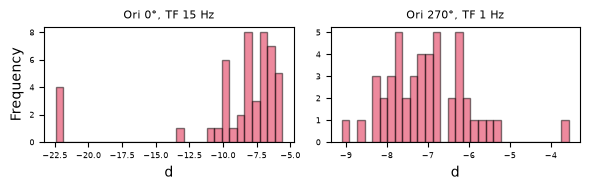

In [33]:
fig, axes = plot_param_histograms(
    fits, 
    param_name="d", 
    bins=30, 
    running_phase=0, 
    trial_keys=top_trial_keys_per_phase[0][:NR_MODELS_TO_PLOT]
    )
plt.show()

fig, axes = plot_param_histograms(
    fits, 
    param_name="d", 
    bins=30, 
    running_phase=1, 
    trial_keys=top_trial_keys_per_phase[1][:NR_MODELS_TO_PLOT]
    )
plt.show()

The offset parameter $d_k$ represents the baseline firing rate of individual neurons.
- The distributions were similar across stimulus conditions and locomotion phases, with only a few outliers.
- Interestingly, one outlier corresponded to neuron 25, which was previously identified as the neuron most strongly correlated with running speed (see notebook correlations_and_onset.ipynb)

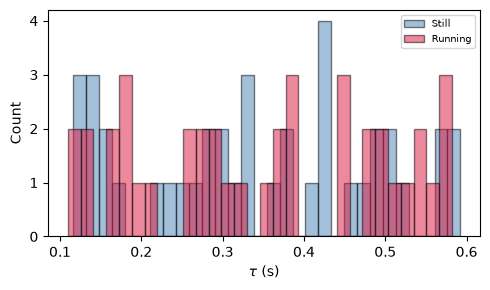

In [34]:
fig, ax = plot_tau_histogram(
    fits, 
    bins=30, 
    figure_size=(5, 3)
)
plt.show()

The latent timescale  provides a further constraint on whether GPFA captures locomotion-related dynamics.
If the latent state reflects running speed fluctuations, its timescale should be comparable to that of the running signal.
The fitted timescales ranged from $0$  to $0.6$ s, largely independent of the locomotion phase.
These timescales only partially overlap with running speed dynamics (note: running frequencies were clipped at 5 Hz).


# 4. Compare latent to running traces

We now plot some traces of latent state variables and compare them to the running trajectory given in this trial. We again plot the models with largest explained variance. 

In [ ]:
NR_MODELS_TO_PLOT = 6

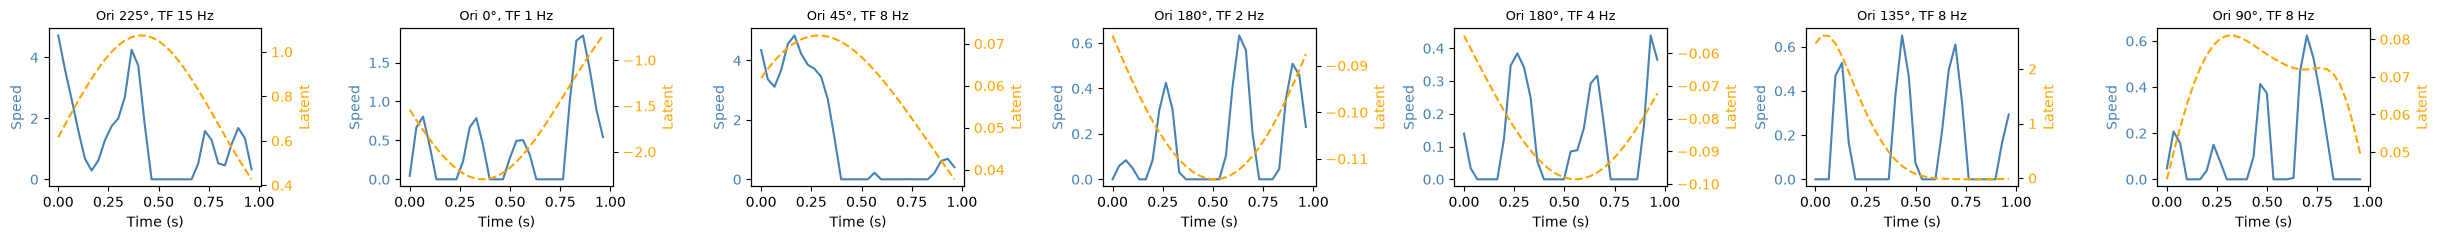

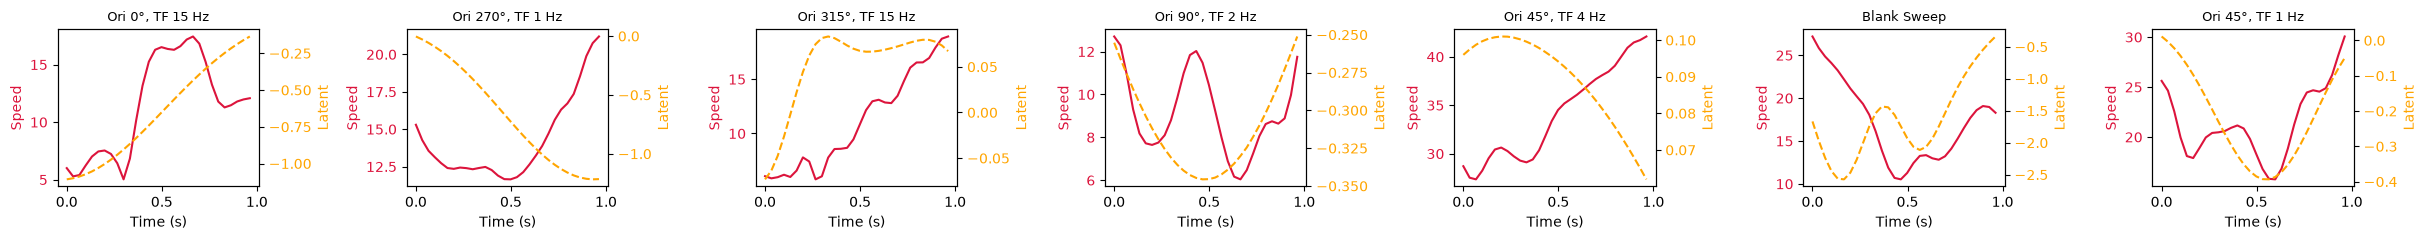

In [43]:
fig, axes = plot_gpfa_latent_and_speed_grid(
    fits,
    trial_keys=top_trial_keys_per_phase[0][:NR_MODELS_TO_PLOT],
    running_phase=0,
    figsize_per_cell=(3.5, 2.5),
    trial_idx=2
)
plt.show()

fig, axes = plot_gpfa_latent_and_speed_grid(
    fits,
    trial_keys=top_trial_keys_per_phase[1][:NR_MODELS_TO_PLOT],
    running_phase=1,
    figsize_per_cell=(3.5, 2.5),
    trial_idx=2
)
plt.show()

The latent network state evolves smoothly over time and can be compared with the (smoothed) running speed trace. 

During periods without movement, the running signal shows faster fluctuations than the latent trace. 

However, in both cases, the running trace is not able to match with the latent trajectory in a consistent way. An exception may be the blank-sweep trials during running, where the latent trajectory becomes more variable and shows some qualitative alignment with changes in the running signal. 


# Intermediate Result

Most models were unable to capture meaningful trial-to-trial noise correlations in the population activity and only reproduced the magnitude of the neuron-intrinsic firing rate baseline. This could be due to sparse spike counts and limited number of trials available for each stimulus condition and running state. 

As a consequence, the inferred latent trajectories cannot be interpreted reliably nor be meaningfully compared to the running speed traces. 

One exception might be the blank-sweep trials, where more trials per condition were available to train on. Here, the models explained more variance, and the latent trajectories showed some qualitative alignment with the running speed.

A natural next step would be to repeat the analysis using the larger raw dataset provided in https://allenswdb.github.io/physiology/ophys/visual-behavior/VB-Ophys.html.
